In [1]:
import torch

from torch import nn
from torch import optim
from torch.utils.data import DataLoader, random_split

from torchvision.models import resnet50

import matplotlib.pyplot as plt

from utils import BaseImageFolderDataset
from utils.transforms import resnet_train_transforms
from utils.trainer import train

In [2]:
GPU = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
SEED = 42

TRAIN_FRACTION = 0.01
LEARNING_RATE = 1e-4
BATCH_SIZE = 16

In [3]:
# PyTorch CPU
torch.manual_seed(SEED)

# PyTorch CUDA
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# PyTorch backend determinism
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
class VisDA2017(BaseImageFolderDataset):
    URL = 'http://csr.bu.edu/ftp/visda17/clf/train.tar'
    ARCHIVE_NAME = 'train.tar'
    EXTRACTED_FOLDER = 'train'

In [5]:
dataset = VisDA2017('./data', transform=resnet_train_transforms, download=True)

In [6]:
# train_size = int(TRAIN_FRACTION * len(dataset))
# val_size = len(dataset) - train_size

train_size = int(TRAIN_FRACTION * len(dataset))
val_size = int(TRAIN_FRACTION * len(dataset))
rest_size = len(dataset) - train_size - val_size

train_dataset, val_dataset, _ = random_split(
    dataset, [train_size, val_size, rest_size])

In [7]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=8,
    pin_memory=True,
    prefetch_factor=4
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=8,
    pin_memory=True,
    prefetch_factor=4
)

In [8]:
model = resnet50(num_classes=12)

In [9]:
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [10]:
loss = nn.CrossEntropyLoss()

In [11]:
metrics = train(
    model,
    train_dataloader,
    val_dataloader,
    optimizer,
    loss,
    epochs=5,
    checkpoint_interval=5,
    checkpoint_path='.',
    device=GPU
)

Epoch   1 | Train Loss: 2.4561 | Train Acc1: 15.36% | Train Acc5: 58.83% | Val Loss: 2.6737 | Val Acc1: 11.78% | Val Acc5: 54.08%


Epoch   2 | Train Loss: 2.3383 | Train Acc1: 19.01% | Train Acc5: 64.08% | Val Loss: 2.3900 | Val Acc1: 16.23% | Val Acc5: 62.74%


Epoch   3 | Train Loss: 2.3106 | Train Acc1: 18.82% | Train Acc5: 64.80% | Val Loss: 2.6054 | Val Acc1: 18.75% | Val Acc5: 60.55%


Epoch   4 | Train Loss: 2.1888 | Train Acc1: 22.79% | Train Acc5: 73.74% | Val Loss: 2.2025 | Val Acc1: 20.66% | Val Acc5: 72.40%


Epoch   5 | Train Loss: 2.0724 | Train Acc1: 26.69% | Train Acc5: 77.52% | Val Loss: 2.0718 | Val Acc1: 28.15% | Val Acc5: 80.27%
Saving checkpoint...OK


In [12]:
def plot_training_metrics(metrics_dict):
    """
    Plot training and validation metrics from a dictionary.

    Args:
        metrics_dict: Dictionary containing lists of metrics for each epoch
                      Expected keys: 'train_loss', 'train_acc1', 'train_acc5',
                                   'val_loss', 'val_acc1', 'val_acc5'
    """
    epochs = range(1, len(metrics_dict['train_loss']) + 1)

    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Loss curves
    ax1.plot(epochs, metrics_dict['train_loss'],
             'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, metrics_dict['val_loss'],
             'r-', label='Validation Loss', linewidth=2)
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training and Validation Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Accuracy curves (Top-1 and Top-5)
    ax2.plot(epochs, metrics_dict['train_acc1'],
             'b-', label='Train Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['val_acc1'],
             'r-', label='Val Top-1', linewidth=2)
    ax2.plot(epochs, metrics_dict['train_acc5'], 'b--',
             label='Train Top-5', linewidth=2, alpha=0.7)
    ax2.plot(epochs, metrics_dict['val_acc5'], 'r--',
             label='Val Top-5', linewidth=2, alpha=0.7)
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy (%)')
    ax2.set_title('Training and Validation Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

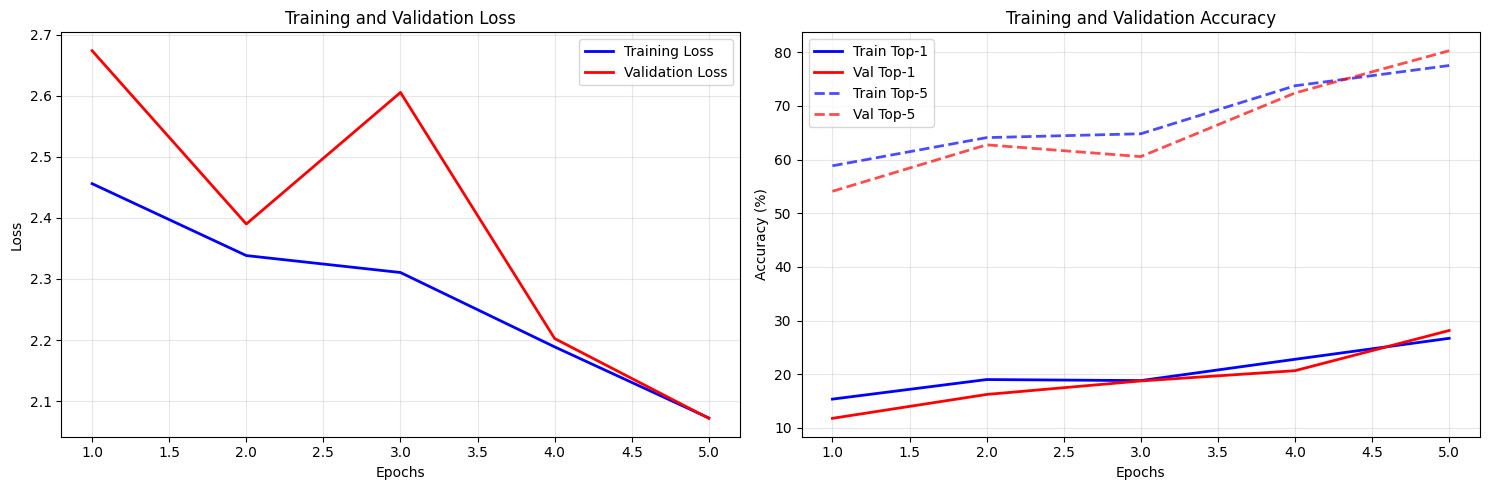

In [13]:
plot_training_metrics(metrics)